In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RNG_SEED = 42

In [2]:
def train_val_test_split(X, y, val_frac=0.15, test_frac=0.15, seed=RNG_SEED):
    n = X.shape[0]
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    n_test = int(n * test_frac)
    n_val = int(n * val_frac)
    test_idx = idx[:n_test]
    val_idx = idx[n_test:n_test + n_val]
    train_idx = idx[n_test + n_val:]
    return X[train_idx], y[train_idx], X[val_idx], y[val_idx], X[test_idx], y[test_idx]

def fit_scaler(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    sigma[sigma == 0] = 1.0
    return mu, sigma

def apply_scaler(X, mu, sigma):
    return (X - mu) / sigma

In [3]:
# Regression metrics
def mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def rmse(y_true, y_pred):
    return np.sqrt(mse(y_true, y_pred))

def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

In [4]:
# Classification metrics
def confusion_counts(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, fp, tn, fn

def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def precision_score(y_true, y_pred):
    tp, fp, tn, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fp) if (tp + fp) > 0 else 0.0

def recall_score(y_true, y_pred):
    tp, fp, tn, fn = confusion_counts(y_true, y_pred)
    return tp / (tp + fn) if (tp + fn) > 0 else 0.0

def f1_score(y_true, y_pred):
    p = precision_score(y_true, y_pred)
    r = recall_score(y_true, y_pred)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

In [5]:
df_reg = pd.read_csv("oil_sales_assignment_dataset.csv")

drop_cols_reg = ["store_name", "sku", "value_sales"]
target_reg = "volume_sales"
cat_cols_reg = ["city", "manufacturer", "brand", "class", "size", "price_bracket"]

df_reg = df_reg.drop(columns=drop_cols_reg)
df_reg_enc = pd.get_dummies(df_reg, columns=cat_cols_reg, drop_first=True)

y_reg = df_reg_enc[target_reg].to_numpy(dtype=float)
X_reg = df_reg_enc.drop(columns=[target_reg]).to_numpy(dtype=float)

print("Feature matrix:", X_reg.shape)

Feature matrix: (2000, 55)


In [6]:
Xr_train, yr_train, Xr_val, yr_val, Xr_test, yr_test = train_val_test_split(X_reg, y_reg)

mu_r, sigma_r = fit_scaler(Xr_train)  # scaler fit ONLY on training data
Xr_train_s = apply_scaler(Xr_train, mu_r, sigma_r)
Xr_val_s = apply_scaler(Xr_val, mu_r, sigma_r)
Xr_test_s = apply_scaler(Xr_test, mu_r, sigma_r)

print("train/val/test:", Xr_train.shape[0], Xr_val.shape[0], Xr_test.shape[0])

train/val/test: 1400 300 300


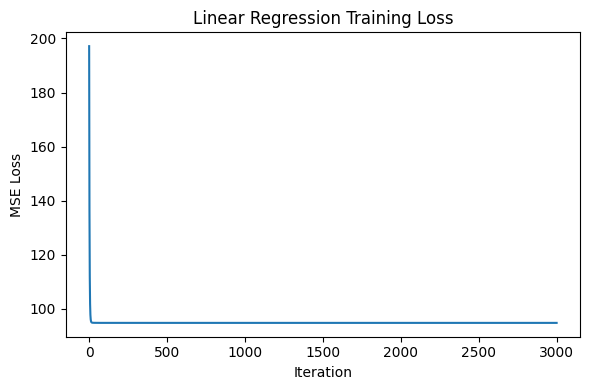

In [7]:
class LinearRegressionScratch:
    def __init__(self, lr=0.1, n_iters=3000):
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        for _ in range(self.n_iters):
            y_pred = X @ self.w + self.b
            error = y_pred - y
            grad_w = (2 / n) * (X.T @ error)
            grad_b = (2 / n) * np.sum(error)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            self.loss_history.append(np.mean(error ** 2))
        return self

    def predict(self, X):
        return X @ self.w + self.b

lin_model = LinearRegressionScratch(lr=0.1, n_iters=3000).fit(Xr_train_s, yr_train)

plt.figure(figsize=(6, 4))
plt.plot(lin_model.loss_history)
plt.xlabel("Iteration"); plt.ylabel("MSE Loss"); plt.title("Linear Regression Training Loss")
plt.tight_layout(); plt.show()

In [8]:
yr_pred_test = lin_model.predict(Xr_test_s)
baseline_pred_reg = np.full_like(yr_test, yr_train.mean())

print("--- Test set: trained model vs mean baseline ---")
print(f"Model    MSE={mse(yr_test, yr_pred_test):.3f}  RMSE={rmse(yr_test, yr_pred_test):.3f}  "
      f"MAE={mae(yr_test, yr_pred_test):.3f}  R2={r2_score(yr_test, yr_pred_test):.3f}")
print(f"Baseline MSE={mse(yr_test, baseline_pred_reg):.3f}  RMSE={rmse(yr_test, baseline_pred_reg):.3f}  "
      f"MAE={mae(yr_test, baseline_pred_reg):.3f}  R2={r2_score(yr_test, baseline_pred_reg):.3f}")
print(f"\n(For reference) train R2 = {r2_score(yr_train, lin_model.predict(Xr_train_s)):.3f}")

--- Test set: trained model vs mean baseline ---
Model    MSE=105.998  RMSE=10.296  MAE=7.766  R2=-0.056
Baseline MSE=100.412  RMSE=10.021  MAE=7.546  R2=-0.000

(For reference) train R2 = 0.033


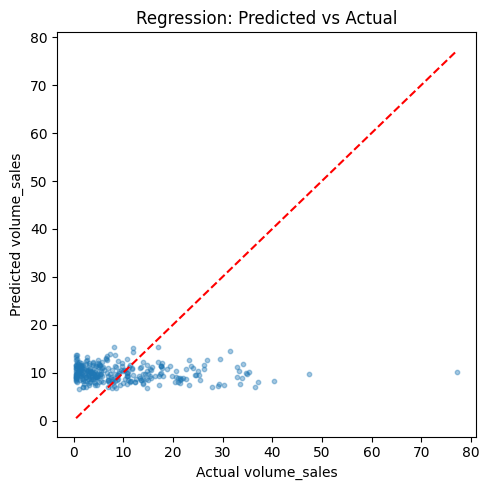

In [9]:
plt.figure(figsize=(5, 5))
plt.scatter(yr_test, yr_pred_test, alpha=0.4, s=10)
lims = [min(yr_test.min(), yr_pred_test.min()), max(yr_test.max(), yr_pred_test.max())]
plt.plot(lims, lims, 'r--')
plt.xlabel("Actual volume_sales"); plt.ylabel("Predicted volume_sales")
plt.title("Regression: Predicted vs Actual")
plt.tight_layout(); plt.show()

In [10]:
residuals = yr_test - yr_pred_test
worst_idx = np.argsort(np.abs(residuals))[-10:]
print("Largest absolute residuals (test set):")
print(np.round(residuals[worst_idx], 2))

Largest absolute residuals (test set):
[24.67 25.02 25.15 25.2  25.94 29.11 29.56 32.06 37.64 66.97]


In [11]:
df_clf = pd.read_csv("heart_disease_risk_2026.csv")
target_clf = "has_heart_disease"

df_clf = df_clf.drop(columns=["patient_id"])
for c in ["exercise_induced_angina", "family_history", "wearable_owner"]:
    df_clf[c] = df_clf[c].astype(int)

cat_cols_clf = ["sex", "chest_pain_type", "smoker_status"]
df_clf_enc = pd.get_dummies(df_clf, columns=cat_cols_clf, drop_first=True)

y_clf = df_clf_enc[target_clf].to_numpy(dtype=float)
X_clf = df_clf_enc.drop(columns=[target_clf]).to_numpy(dtype=float)

print("Feature matrix:", X_clf.shape)
print("Class balance (0/1):", np.bincount(y_clf.astype(int)))

Feature matrix: (9000, 28)
Class balance (0/1): [6273 2727]


In [12]:
Xc_train, yc_train, Xc_val, yc_val, Xc_test, yc_test = train_val_test_split(X_clf, y_clf)

mu_c, sigma_c = fit_scaler(Xc_train)
Xc_train_s = apply_scaler(Xc_train, mu_c, sigma_c)
Xc_val_s = apply_scaler(Xc_val, mu_c, sigma_c)
Xc_test_s = apply_scaler(Xc_test, mu_c, sigma_c)

print("train/val/test:", Xc_train.shape[0], Xc_val.shape[0], Xc_test.shape[0])

train/val/test: 6300 1350 1350


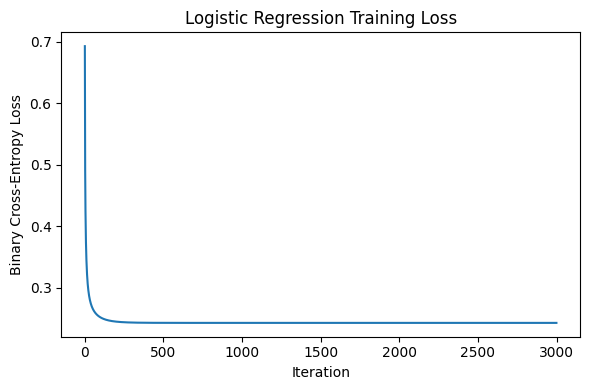

In [13]:
def sigmoid(z):
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

class LogisticRegressionScratch:
    def __init__(self, lr=0.5, n_iters=3000):
        self.lr = lr
        self.n_iters = n_iters
        self.loss_history = []

    def fit(self, X, y):
        n, d = X.shape
        self.w = np.zeros(d)
        self.b = 0.0
        for _ in range(self.n_iters):
            y_pred = sigmoid(X @ self.w + self.b)
            error = y_pred - y
            grad_w = (1 / n) * (X.T @ error)
            grad_b = (1 / n) * np.sum(error)
            self.w -= self.lr * grad_w
            self.b -= self.lr * grad_b
            eps = 1e-9
            loss = -np.mean(y * np.log(y_pred + eps) + (1 - y) * np.log(1 - y_pred + eps))
            self.loss_history.append(loss)
        return self

    def predict_proba(self, X):
        return sigmoid(X @ self.w + self.b)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

log_model = LogisticRegressionScratch(lr=0.5, n_iters=3000).fit(Xc_train_s, yc_train)

plt.figure(figsize=(6, 4))
plt.plot(log_model.loss_history)
plt.xlabel("Iteration"); plt.ylabel("Binary Cross-Entropy Loss"); plt.title("Logistic Regression Training Loss")
plt.tight_layout(); plt.show()

In [14]:
yc_pred_test = log_model.predict(Xc_test_s)
majority_class = int(round(yc_train.mean()))
baseline_pred_clf = np.full_like(yc_test, majority_class)

tp, fp, tn, fn = confusion_counts(yc_test, yc_pred_test)
print(f"Confusion matrix -> TP={tp}  FP={fp}  TN={tn}  FN={fn}\n")
print("--- Test set: trained model vs majority-class baseline ---")
print(f"Model    Acc={accuracy(yc_test, yc_pred_test):.3f}  Prec={precision_score(yc_test, yc_pred_test):.3f}  "
      f"Rec={recall_score(yc_test, yc_pred_test):.3f}  F1={f1_score(yc_test, yc_pred_test):.3f}")
print(f"Baseline Acc={accuracy(yc_test, baseline_pred_clf):.3f}  Prec={precision_score(yc_test, baseline_pred_clf):.3f}  "
      f"Rec={recall_score(yc_test, baseline_pred_clf):.3f}  F1={f1_score(yc_test, baseline_pred_clf):.3f}")

Confusion matrix -> TP=320  FP=54  TN=896  FN=80

--- Test set: trained model vs majority-class baseline ---
Model    Acc=0.901  Prec=0.856  Rec=0.800  F1=0.827
Baseline Acc=0.704  Prec=0.000  Rec=0.000  F1=0.000


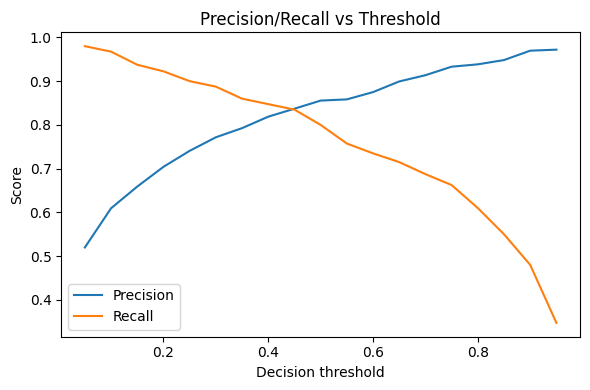

In [15]:
thresholds = np.linspace(0.05, 0.95, 19)
precisions, recalls = [], []
for t in thresholds:
    pred_t = log_model.predict(Xc_test_s, threshold=t)
    precisions.append(precision_score(yc_test, pred_t))
    recalls.append(recall_score(yc_test, pred_t))

plt.figure(figsize=(6, 4))
plt.plot(thresholds, precisions, label="Precision")
plt.plot(thresholds, recalls, label="Recall")
plt.xlabel("Decision threshold"); plt.ylabel("Score"); plt.legend()
plt.title("Precision/Recall vs Threshold")
plt.tight_layout(); plt.show()